# Iris dataset - Regressão Logística - 3 classes

## Objetivos

Este notebook ilustra o problema de classificação.

O objetivo é classificar as amostras da Íris em 3 classes.
- o alvo é o índice da classe: 0, 1 ou 2
- função de perda é Entropia Cruzada
- rede é uma camada densa linear com duas entradas e três saídas (n. de classes)

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmax_CrossEntropy_Otimizacao.png)

## Importação das bibliotecas

In [ ]:
%matplotlib inline
import os
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F

from IPython import display
from sklearn.model_selection import train_test_split

## Dataset: Leitura, normalização e visualização dos dados

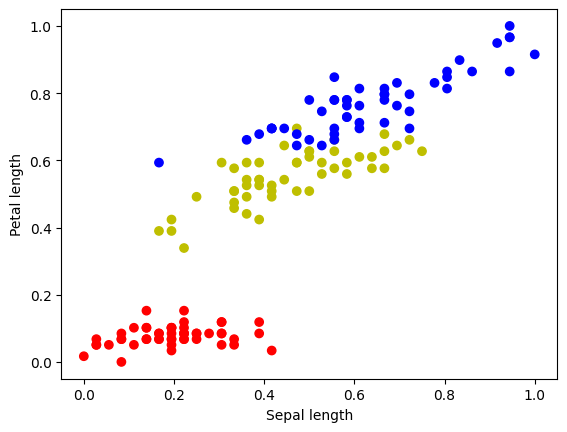

In [ ]:
iris = load_iris()
X = iris.data[:,::2]  # comprimento das sépalas e pétalas, indices 0 e 2
# normalização
Xc = X - X.min(axis=0)
Xs = Xc.max(axis=0)
Xc = Xc/Xs

Y = iris.target
colors = np.array(['r','y','b'])
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y])
plt.xlabel('Sepal length')
plt.ylabel('Petal length')
plt.show()

# Dividindo Dataset em Treinamento E Validação

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(Xc, Y, test_size=0.2, random_state=42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 2)
(30, 2)
(120,)
(30,)


### Prepara os dados para o PyTorch

In [ ]:
X_train_tensor = torch.FloatTensor(x_train)  # Entrada é FloatTensor
Y_train_tensor = torch.LongTensor(y_train)    # Classe é LongTensor
X_test_tensor = torch.FloatTensor(x_test)  # Entrada é FloatTensor
Y_test_tensor = torch.LongTensor(y_test)    # Classe é LongTensor

In [ ]:
Y_train_tensor

tensor([0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2, 1, 0,
        2, 1, 0, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2, 1, 1, 2, 1,
        0, 1, 2, 0, 0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1, 0, 0, 2, 2, 0, 0,
        0, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 1, 1, 1, 0, 1, 1, 0, 1,
        2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2, 1, 1, 2, 2, 0, 1, 2, 0, 1, 2])

In [ ]:
X_train_tensor

tensor([[0.0833, 0.0000],
        [0.3889, 0.0847],
        [0.6667, 0.5763],
        [0.1389, 0.1017],
        [0.0278, 0.0508],
        [0.5556, 0.6780],
        [0.5833, 0.5932],
        [0.2500, 0.0847],
        [0.1944, 0.0678],
        [0.2500, 0.0847],
        [0.4167, 0.6949],
        [0.4722, 0.5932],
        [0.6667, 0.6271],
        [0.3056, 0.0508],
        [0.3056, 0.0847],
        [0.3333, 0.4576],
        [0.5556, 0.6949],
        [0.5833, 0.7627],
        [0.6389, 0.5763],
        [0.8056, 0.8644],
        [0.3889, 0.5424],
        [0.9167, 0.9492],
        [0.3611, 0.5932],
        [0.2222, 0.0678],
        [0.9444, 0.9661],
        [0.4167, 0.5254],
        [0.2500, 0.0678],
        [0.1944, 0.0508],
        [0.2222, 0.1525],
        [0.1944, 0.4237],
        [0.5556, 0.6610],
        [0.1389, 0.1525],
        [0.1944, 0.1017],
        [0.2222, 0.1186],
        [0.3611, 0.5424],
        [0.2222, 0.0847],
        [0.3889, 0.5424],
        [0.9444, 0.9661],
        [0.0

## Construindo o modelo da rede

A saída da rede é composta por um neurônio para cada classe. A saída é denominada *scores* ou logitos:

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLogisticaRede_2_3.png)

In [ ]:
model = nn.Linear(2,3)  # 2 entradas e 3 saídas

In [ ]:
model.state_dict()

OrderedDict([('weight',
              tensor([[-0.1102, -0.2030],
                      [ 0.5229,  0.0853],
                      [ 0.2370,  0.1249]])),
             ('bias', tensor([ 0.0600, -0.2041,  0.6807]))])

### Fazendo um predict

In [ ]:
out = model(X_train_tensor[:4,:]) # 4 amostras
out

tensor([[ 5.0794e-02, -1.6049e-01,  7.0040e-01],
        [-8.9850e-05,  6.5016e-03,  7.8339e-01],
        [-1.3051e-01,  1.9367e-01,  9.1062e-01],
        [ 2.4023e-02, -1.2277e-01,  7.2627e-01]], grad_fn=<AddmmBackward0>)

In [ ]:
oo = F.softmax(out,dim=1)
oo

tensor([[0.2685, 0.2174, 0.5141],
        [0.2383, 0.2399, 0.5217],
        [0.1917, 0.2652, 0.5431],
        [0.2576, 0.2224, 0.5199]], grad_fn=<SoftmaxBackward0>)

### Calculando as probabilidades com Softmax

- [Wikipedia:Softmax_function](https://en.wikipedia.org/wiki/Softmax_function)

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/softmax.png)

In [ ]:
F.softmax(out,dim=1)*100

tensor([[26.8505, 21.7366, 51.4129],
        [23.8340, 23.9916, 52.1745],
        [19.1743, 26.5160, 54.3096],
        [25.7615, 22.2444, 51.9941]], grad_fn=<MulBackward0>)

### Predição da classe

In [ ]:
prob,y_pred = torch.max(F.softmax(out,dim=1),dim=1)
print(y_pred)
print(prob)

tensor([2, 2, 2, 2])
tensor([0.5141, 0.5217, 0.5431, 0.5199], grad_fn=<MaxBackward0>)


## Treinamento

### Classe para visualização dinâmica

In [ ]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

def predict_prob(model, inputs):
    outputs = model(Variable(inputs))
    outputs = F.softmax(outputs,dim=1)
    predicts, _ = torch.max(outputs, 1)

    return predicts.data.numpy()

class MyPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(12, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 3, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.set_title('Perda x Época')
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 3, 2)
        self.ax2.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax2.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax2.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax2.set_ylabel('Largura da Sepala')#,fontsize=28)
        self.ax2.set_title('Fronteiras de decisão')

        self.ax3 = self.fig.add_subplot(1, 3, 3)
        self.ax3.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax3.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax3.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax3.set_ylabel('Largura da Sepala')#,fontsize=28)
        self.ax3.set_title('Máxima probabilidade')

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                #Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
                Zc = predict(self.model,torch.FloatTensor(self.X_grid))
                Zc = Zc.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Zc, cmap=plt.cm.Paired)
                colors = np.array(['r','y','b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                Zp = predict_prob(self.model,torch.FloatTensor(self.X_grid))
                Zp = Zp.reshape(self.xx.shape)

                self.ax3.pcolormesh(self.xx, self.yy, Zp, cmap=plt.cm.magma)
                colors = np.array(['r','y','b'])
                self.ax3.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

### Laço principal de treinamento da Regressão Logística por Softmax

In [ ]:
lr = 0.3

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

In [ ]:
nb_epoch = 10000

losses = []
losses_test = []
acc_list = []
acc_test_list = []
for i in range(nb_epoch):
    # predict da rede
    output = model(X_train_tensor)
    output_test = model(X_test_tensor)

    # calcula a perda
    loss = criterion(output, Y_train_tensor)
    loss_test = criterion(output_test, Y_test_tensor)

    # Faz o backpropagation para calcular os gradientes e otimizar parâmetros
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data.item())
    losses_test.append(loss_test.data.item())

    _, class_max = torch.max(F.softmax(output,dim=1),dim=1)
    _, class_test_max = torch.max(F.softmax(output_test,dim=1),dim=1)
    acc_list.append((class_max == Y_train_tensor).float().mean())
    acc_test_list.append((class_test_max == Y_test_tensor).float().mean())

    final_loss = loss.data.item()

print('Final loss:', final_loss)

Final loss: 0.1545424908399582


In [ ]:
print(acc_list)

[tensor(0.3250), tensor(0.3250), tensor(0.3250), tensor(0.3250), tensor(0.3250), tensor(0.3250), tensor(0.3250), tensor(0.3250), tensor(0.3250), tensor(0.3250), tensor(0.3583), tensor(0.4000), tensor(0.4333), tensor(0.5000), tensor(0.5833), tensor(0.6167), tensor(0.6500), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6583), tensor(0.6667), tensor(0.6667), tensor(0.6667), tensor(0.6667), tensor(0.6667), tensor(0.6750), tensor(0.6750), tensor(0.6750), tensor(0.6833), tensor(0.6917), tensor(0.6917), tensor(0.6917), tensor(

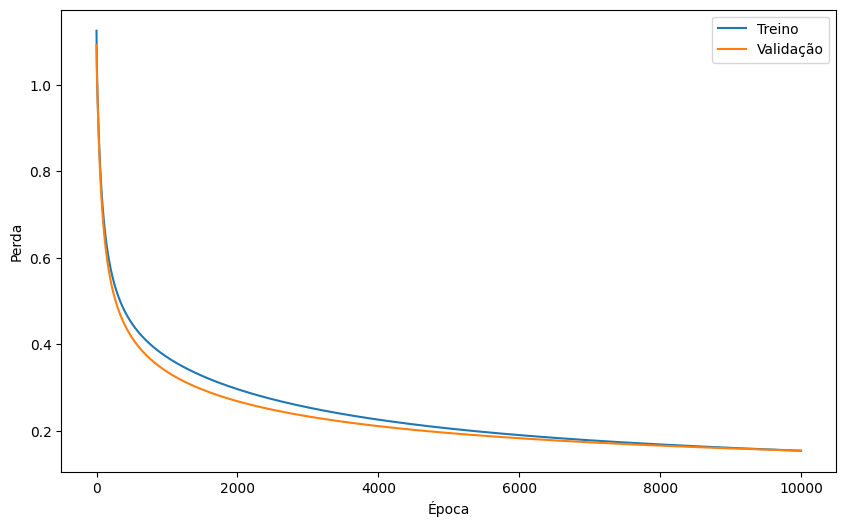

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(list(range(nb_epoch)), losses, label='Treino')
plt.plot(list(range(nb_epoch)), losses_test, label='Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.show()

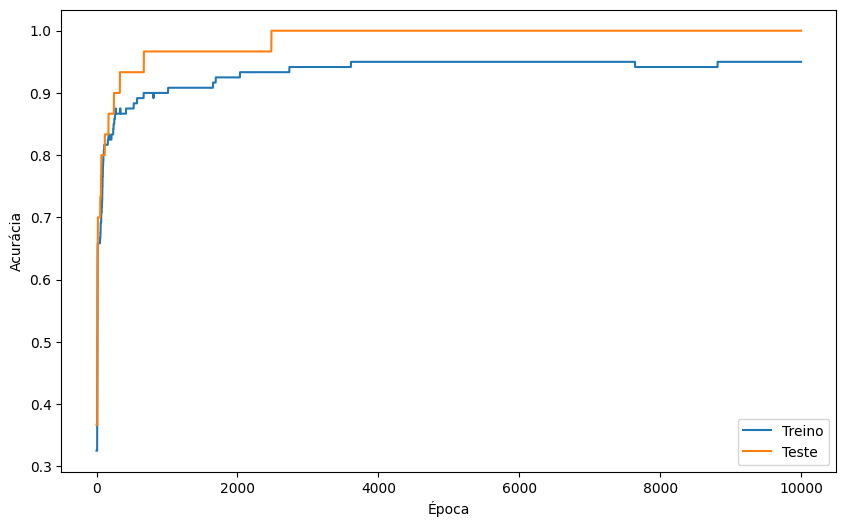

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(list(range(nb_epoch)), acc_list, label='Treino')
plt.plot(list(range(nb_epoch)), acc_test_list, label='Teste')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

## Avaliação

### Parâmetros após treinamento

In [ ]:
model.state_dict()

OrderedDict([('weight',
              tensor([[ -2.2094, -19.5606],
                      [  3.4350,  -2.2739],
                      [ -0.5760,  21.8415]])),
             ('bias', tensor([  8.9350,   2.6564, -11.0548]))])

### Salvando os parâmetros treinados

In [ ]:
os.makedirs('../models',exist_ok=True)
torch.save(model.state_dict(),'../models/RegrLog_Iris.pt')

In [ ]:
! ls ../models/

RegrLog_Iris.pt


In [ ]:
nn.init.constant(model.weight,0)
model.state_dict()

/tmp/ipython-input-952960416.py:1: FutureWarning: `nn.init.constant` is now deprecated in favor of `nn.init.constant_`.
  nn.init.constant(model.weight,0)


OrderedDict([('weight',
              tensor([[0., 0.],
                      [0., 0.],
                      [0., 0.]])),
             ('bias', tensor([  8.9350,   2.6564, -11.0548]))])

### Recuperando os pesos salvos

In [ ]:
param_saved = torch.load('../models/RegrLog_Iris.pt')
model.load_state_dict(param_saved)
model.state_dict()

OrderedDict([('weight',
              tensor([[ -2.2094, -19.5606],
                      [  3.4350,  -2.2739],
                      [ -0.5760,  21.8415]])),
             ('bias', tensor([  8.9350,   2.6564, -11.0548]))])

### Exatidão (acurácia) do classificador

Acurácia indica o número de acertos sobre o número total de amostras

In [ ]:
Y_pred = predict(model, X_train_tensor)
accuracy = (Y_pred == Y_train_tensor).float().mean()
print('Training Accuracy: ', accuracy)

Training Accuracy:  tensor(0.9500)


### Matriz de confusão

In [ ]:
import pandas as pd
pd.crosstab(Y_pred, y_train)

col_0,0,1,2
row_0,,,
0,40,0,0
1,0,38,3
2,0,3,36


## Atividades

### Perguntas:

**1. Observe que se após o treinamento, a célula for executada novamente, ela continua utilizando os parâmetros treinados até sua última execução. O que é preciso fazer para que o treinamento comece deste o início, como da primeira vez que foi executado?**

Para que o treinamento recomece do início, é necessário reinicializar o modelo e o otimizador, criando novos pesos. Caso contrário, o PyTorch continua usando os parâmetros aprendidos anteriormente.

Exemplo:
model = LogisticRegressionNet()  # cria pesos novos
optimizer = torch.optim.SGD(model.parameters(), lr=0.15)

**2. Experimente refazer o treinamento com diferentes valores de learning rate**

Learning rates pequenos levam a uma convergência lenta, enquanto valores muito altos podem causar oscilações ou impedir a convergência. Valores intermediários levam ao melhor aprendizado, com menos ruido nos graficos.

### Exercícios:

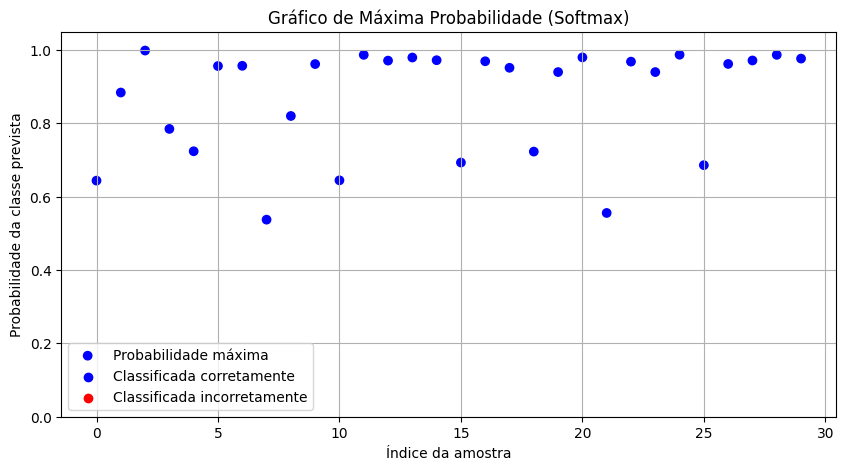

In [ ]:
probs = F.softmax(model(X_test_tensor), dim=1)
y_pred = torch.argmax(probs, dim=1)

# Calculando probabilidade máxima por amostra
max_probs, _ = torch.max(probs, dim=1)

# Identificando acertos e erros
correct = (y_pred == Y_test_tensor)

# Plot
plt.figure(figsize=(10,5))
plt.scatter(range(len(max_probs)), max_probs.detach().numpy(),
            c=['blue' if c else 'red' for c in correct.detach().numpy()],
            label="Probabilidade máxima")

plt.xlabel("Índice da amostra")
plt.ylabel("Probabilidade da classe prevista")
plt.title("Gráfico de Máxima Probabilidade (Softmax)")
plt.ylim([0, 1.05])

# Legendas
plt.scatter([], [], color='blue', label='Classificada corretamente')
plt.scatter([], [], color='red',  label='Classificada incorretamente')
plt.legend()
plt.grid(True)
plt.show()

1. Observando o gráfico de máxima probabilidade, responda:
    1. Qual é a amostra classificada corretamente, com maior probabilidade?

      **3**

    2. Qual é a amostra classificada erradamente, com maior probabilidade?

      **Nenhuma**

    3. Qual é a amostra classificada corretamente, com menor probabilidade?

      **7**

    4. Qual é a amostra classificada erradamente, com menor probabilidade?

      **Nenhuma**
      
2. Quantos parâmetros possui esta rede? Quantos são da camada densa e quantos são de bias?
3. Quantas entradas e quantas saídas esta rede possui?
4. Como se pode calcular a acurácia a partir da matriz de confusão?
5. O que faz a função `torch.max`? Quantos parâmetros ela retorna e quais seus significados?
    - http://pytorch.org/docs/master/torch.html?highlight=torch%20max#torch.max

### 2. Quantos parâmetros possui esta rede? Quantos são da camada densa e quantos são de bias?


In [ ]:
parametros = sum(p.numel() for p in model.parameters())
print(f"Quantidade de parametros: {parametros}")

parametros_b = model.bias.numel()
print(f"Quantidade de parametros de bias: {parametros_b}")

parametros_w = model.weight.numel()
print(f"Quantidade de parametros de pesos: {parametros_w}")

Quantidade de parametros: 9
Quantidade de parametros de bias: 3
Quantidade de parametros de pesos: 6


### 3. Quantas entradas e quantas saídas esta rede possui?


In [ ]:
print(f"Entradas da rede: {model.in_features}")
print(f"Saídas da rede: {model.out_features}")

Entradas da rede: 2
Saídas da rede: 3


### Como se pode calcular a acurácia a partir da matriz de confusão?
A acurácia é calculada dividindo-se o número de acertos — representados pelos valores da diagonal principal da matriz de confusão — pelo total de amostras.

### O que faz a função torch.max? Quantos parâmetros ela retorna e quais seus significados?

A função torch.max retorna o valor máximo de um tensor.

Quando chamada como torch.max(tensor, dim), ela retorna dois parâmetros:

**values** – os valores máximos ao longo da dimensão escolhida

**indices** – os índices onde esses valores ocorrem (por exemplo, a classe prevista)

Isso é usado para determinar qual classe tem a maior probabilidade no vetor de saída do modelo.

## Principais aprendizados

As questões permitiram compreender como interpretar o gráfico de máxima probabilidade, identificando as amostras com maior e menor confiança do modelo e confirmando que não houveram erros de classificação. Também foi calculado o número total de parâmetros da rede, separando pesos e bias, além de identificar quantas entradas e saídas compõem o modelo. Por fim, revisamos o funcionamento da função torch.max, entendendo que ela retorna o valor máximo e o índice correspondente, fundamentais para determinar a classe prevista a partir das probabilidades do modelo.